# Random Forest - SLCE3 (Dataset Base)
## Analise comparativa de modelos de Machine Learning - Agro Brasil - TCC

Este notebook implementa modelos Random Forest para prever se o preco de fechamento das acoes SLCE3 ira subir ou nao em diferentes horizontes temporais (3, 7, 15 e 30 dias).

**Dataset utilizado:** Dataset base (Close, Low, High, Open).

**Target:** Classificacao binaria (1 = Alta, 0 = Baixa/Estavel)

### Importacao das bibliotecas e carregamento do dataset

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, accuracy_score, precision_score, 
                             recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# Configuracao para salvar graficos
OUTPUT_DIR = './'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Carrega o dataset tratado para classificacao
df = pd.read_csv('../../../../datasets/datasets_base/classificacao/SLCE3_tratado.csv', index_col=0, parse_dates=True)

print('='*60)
print('DATASET SLCE3 - RANDOM FOREST (BASE)')
print('='*60)
print(f'\nShape: {df.shape}')
print('\nColunas disponiveis:')
print(df.columns.tolist())
print('\nPrimeiras 5 linhas:')
print(df.head())
print('\nDistribuicao das classes target:')
for col in ['target_3d', 'target_7d', 'target_15d', 'target_30d']:
    if col in df.columns:
        dist = df[col].value_counts()
        pct = df[col].mean()
        print(f'  {col}: {dist.to_dict()} (Taxa de alta: {pct:.1%})')

DATASET SLCE3 - RANDOM FOREST (BASE)

Shape: (1708, 9)

Colunas disponiveis:
['Close', 'High', 'Low', 'Open', 'Volume', 'target_3d', 'target_7d', 'target_15d', 'target_30d']

Primeiras 5 linhas:
               Close      High       Low      Open   Volume  target_3d  \
Date                                                                     
2018-01-02  3.077934  3.103537  2.972182  2.972182  1227908          1   
2018-01-03  3.104650  3.215968  3.067915  3.077933  2494536          1   
2018-01-04  3.092405  3.198157  3.055670  3.104650  2957724          1   
2018-01-05  3.150290  3.166988  3.069028  3.138046  2140248          1   
2018-01-08  3.133592  3.183685  3.112442  3.150290  1613172          1   

            target_7d  target_15d  target_30d  
Date                                           
2018-01-02          1           1           1  
2018-01-03          1           1           1  
2018-01-04          1           1           1  
2018-01-05          1           1           1 

### Preparacao dos dados para modelagem

In [2]:
# Definir features base
base_features = ['Close', 'Low', 'High', 'Open']
X = df[base_features].copy()

# Definir targets (variaveis dependentes) - classificacao binaria
targets = {
    '3d': df['target_3d'],
    '7d': df['target_7d'],
    '15d': df['target_15d'],
    '30d': df['target_30d']
}

print('Variaveis independentes (X):')
print(X.columns.tolist())
print(f'\nShape de X: {X.shape}')

print('\nTargets (classificacao binaria):')
for name, target in targets.items():
    print(f'  - {name}: {target.name} (1=Alta, 0=Baixa)')

Variaveis independentes (X):
['Close', 'Low', 'High', 'Open']

Shape de X: (1708, 4)

Targets (classificacao binaria):
  - 3d: target_3d (1=Alta, 0=Baixa)
  - 7d: target_7d (1=Alta, 0=Baixa)
  - 15d: target_15d (1=Alta, 0=Baixa)
  - 30d: target_30d (1=Alta, 0=Baixa)


### Treinamento dos Modelos Random Forest

In [3]:
print('MODELOS RANDOM FOREST - SLCE3 (BASE)')
print('='*60)

# Dicionario para armazenar modelos treinados e metricas
models = {}

rf_params = {
    'n_estimators': 300,
    'max_depth': None,
    'min_samples_split': 2,
    'min_samples_leaf': 1,
    'max_features': 'sqrt',
    'random_state': 42,
    'n_jobs': -1
}

for period, y in targets.items():
    # Remover NaN
    mask = ~(X.isnull().any(axis=1) | y.isnull())
    X_clean = X[mask]
    y_clean = y[mask]

    # Divisao treino-teste (80/20) com estratificacao
    X_train, X_test, y_train, y_test = train_test_split(
        X_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean)

    # Criar e treinar modelo
    model = RandomForestClassifier(**rf_params)
    model.fit(X_train, y_train)

    # Fazer predicoes
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Calcular metricas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    # Metricas especificas para classe Alta
    precision_alta = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    recall_alta = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1_alta = f1_score(y_test, y_pred, pos_label=1, zero_division=0)

    # AUC-ROC
    auc_roc = roc_auc_score(y_test, y_pred_proba)

    # Armazenar modelo e metricas
    models[period] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'precision_alta': precision_alta,
        'recall_alta': recall_alta,
        'f1_alta': f1_alta,
        'auc_roc': auc_roc,
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }

    print(f'\nMODELO {period.upper()} - Classificacao {period} futuro:')
    print(f'  Accuracy: {accuracy:.4f}')
    print(f'  Precision (weighted): {precision:.4f}')
    print(f'  Recall (weighted): {recall:.4f}')
    print(f'  F1-Score (weighted): {f1:.4f}')
    print(f'  AUC-ROC: {auc_roc:.4f}')
    print('  --- Classe Alta ---')
    print(f'  Precision (Alta): {precision_alta:.4f}')
    print(f'  Recall (Alta): {recall_alta:.4f}')
    print(f'  F1-Score (Alta): {f1_alta:.4f}')

print('\n' + '='*60)
print('OK - 4 modelos treinados com sucesso!')
print('='*60)

MODELOS RANDOM FOREST - SLCE3 (BASE)

MODELO 3D - Classificacao 3d futuro:
  Accuracy: 0.5322
  Precision (weighted): 0.5323
  Recall (weighted): 0.5322
  F1-Score (weighted): 0.5322
  AUC-ROC: 0.5537
  --- Classe Alta ---
  Precision (Alta): 0.5407
  Recall (Alta): 0.5345
  F1-Score (Alta): 0.5376

MODELO 7D - Classificacao 7d futuro:
  Accuracy: 0.6433
  Precision (weighted): 0.6465
  Recall (weighted): 0.6433
  F1-Score (weighted): 0.6435
  AUC-ROC: 0.7145
  --- Classe Alta ---
  Precision (Alta): 0.6788
  Recall (Alta): 0.6188
  F1-Score (Alta): 0.6474

MODELO 15D - Classificacao 15d futuro:
  Accuracy: 0.6433
  Precision (weighted): 0.6439
  Recall (weighted): 0.6433
  F1-Score (weighted): 0.6435
  AUC-ROC: 0.7247
  --- Classe Alta ---
  Precision (Alta): 0.6704
  Recall (Alta): 0.6557
  F1-Score (Alta): 0.6630

MODELO 30D - Classificacao 30d futuro:
  Accuracy: 0.6813
  Precision (weighted): 0.6803
  Recall (weighted): 0.6813
  F1-Score (weighted): 0.6807
  AUC-ROC: 0.7581
  --- 

### Tabela Resumo das Metricas

In [4]:
# Criar DataFrame com resumo das metricas
metrics_summary = pd.DataFrame({
    'Horizonte': ['3 dias', '7 dias', '15 dias', '30 dias'],
    'Accuracy': [models['3d']['accuracy'], models['7d']['accuracy'], models['15d']['accuracy'], models['30d']['accuracy']],
    'Precision': [models['3d']['precision'], models['7d']['precision'], models['15d']['precision'], models['30d']['precision']],
    'Recall': [models['3d']['recall'], models['7d']['recall'], models['15d']['recall'], models['30d']['recall']],
    'F1-Score': [models['3d']['f1'], models['7d']['f1'], models['15d']['f1'], models['30d']['f1']],
    'AUC-ROC': [models['3d']['auc_roc'], models['7d']['auc_roc'], models['15d']['auc_roc'], models['30d']['auc_roc']]
})

print('\nRESUMO DAS METRICAS - SLCE3 (BASE)')
print('='*60)
print(metrics_summary.to_string(index=False))

# Salvar metricas em CSV
metrics_summary.to_csv(f'{OUTPUT_DIR}metricas_slce3_base.csv', index=False)
print('\nOK - Metricas salvas em metricas_slce3_base.csv')


RESUMO DAS METRICAS - SLCE3 (BASE)
Horizonte  Accuracy  Precision   Recall  F1-Score  AUC-ROC
   3 dias  0.532164   0.532264 0.532164  0.532196 0.553657
   7 dias  0.643275   0.646485 0.643275  0.643470 0.714526
  15 dias  0.643275   0.643940 0.643275  0.643520 0.724662
  30 dias  0.681287   0.680331 0.681287  0.680663 0.758139

OK - Metricas salvas em metricas_slce3_base.csv


---
# Analises Graficas

### Matrizes de Confusao

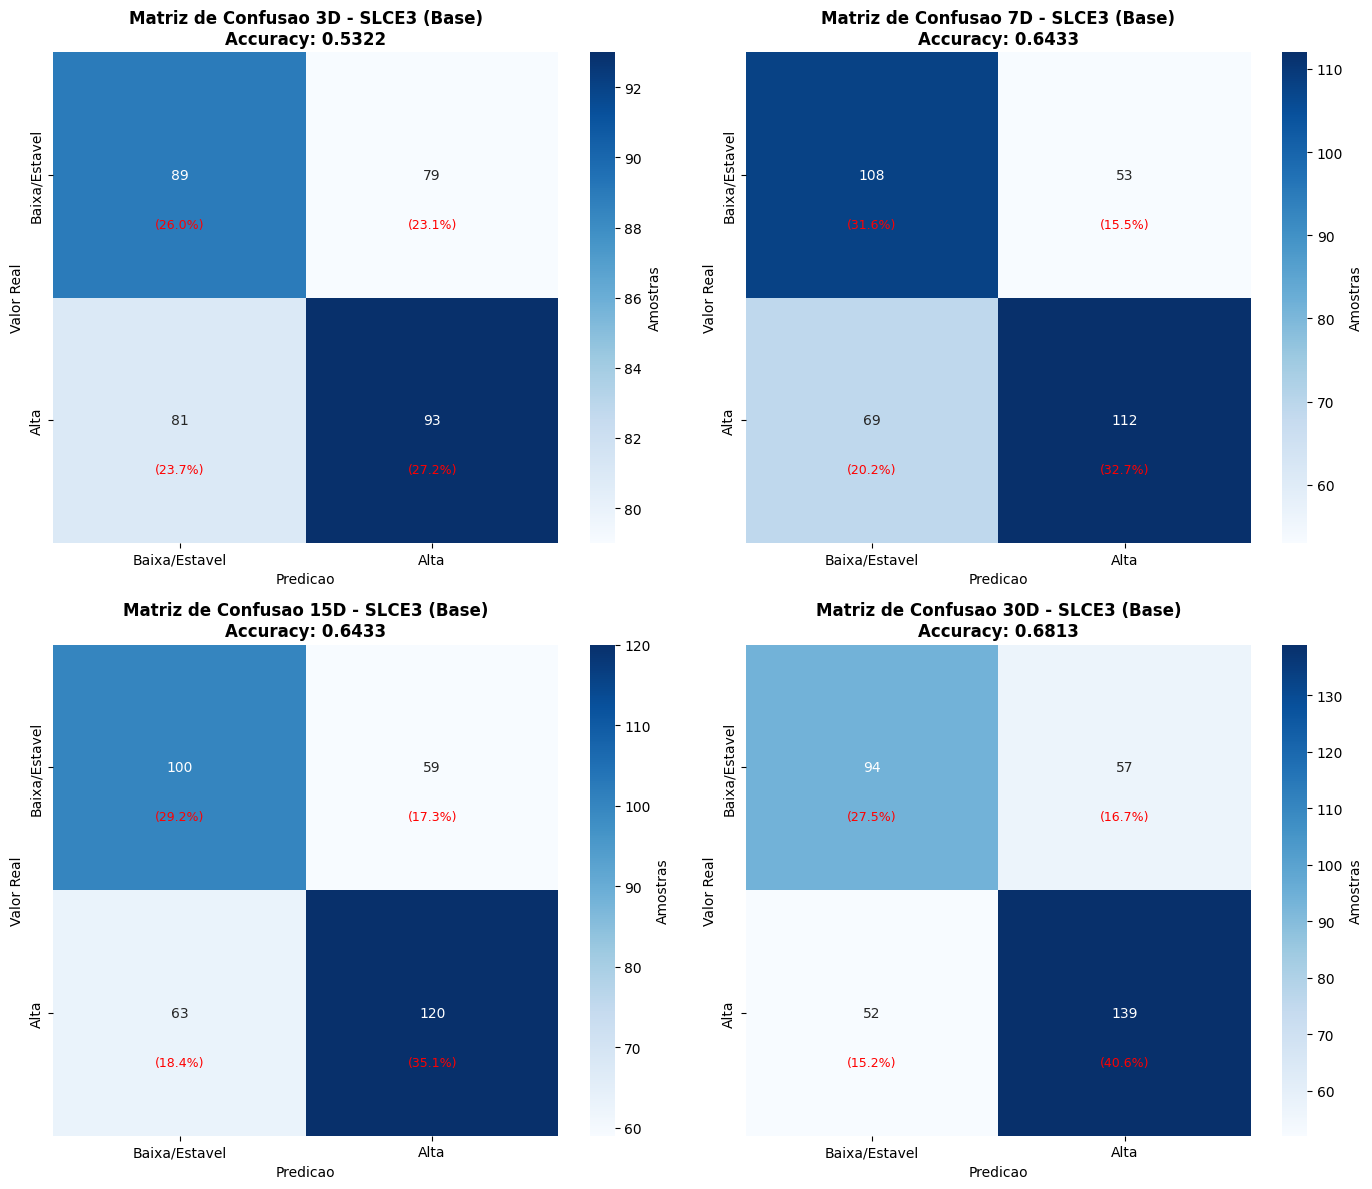

OK - Matrizes de confusao salvas


In [5]:
# Matrizes de Confusao
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (period, model_data) in enumerate(models.items()):
    y_test = model_data['y_test']
    y_pred = model_data['y_pred']

    cm = confusion_matrix(y_test, y_pred)

    ax = axes[idx]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Baixa/Estavel', 'Alta'],
                yticklabels=['Baixa/Estavel', 'Alta'],
                cbar_kws={'label': 'Amostras'})

    ax.set_title(f'Matriz de Confusao {period.upper()} - SLCE3 (Base)\nAccuracy: {model_data["accuracy"]:.4f}', fontweight='bold')
    ax.set_xlabel('Predicao')
    ax.set_ylabel('Valor Real')

    # Adicionar porcentagens
    total = cm.sum()
    for i in range(2):
        for j in range(2):
            pct = (cm[i, j] / total) * 100
            ax.text(j + 0.5, i + 0.7, f'({pct:.1f}%)', ha='center', va='center', fontsize=9, color='red')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}matriz_confusao_slce3_base.png', dpi=300, bbox_inches='tight')
plt.show()
print('OK - Matrizes de confusao salvas')

### Curvas ROC

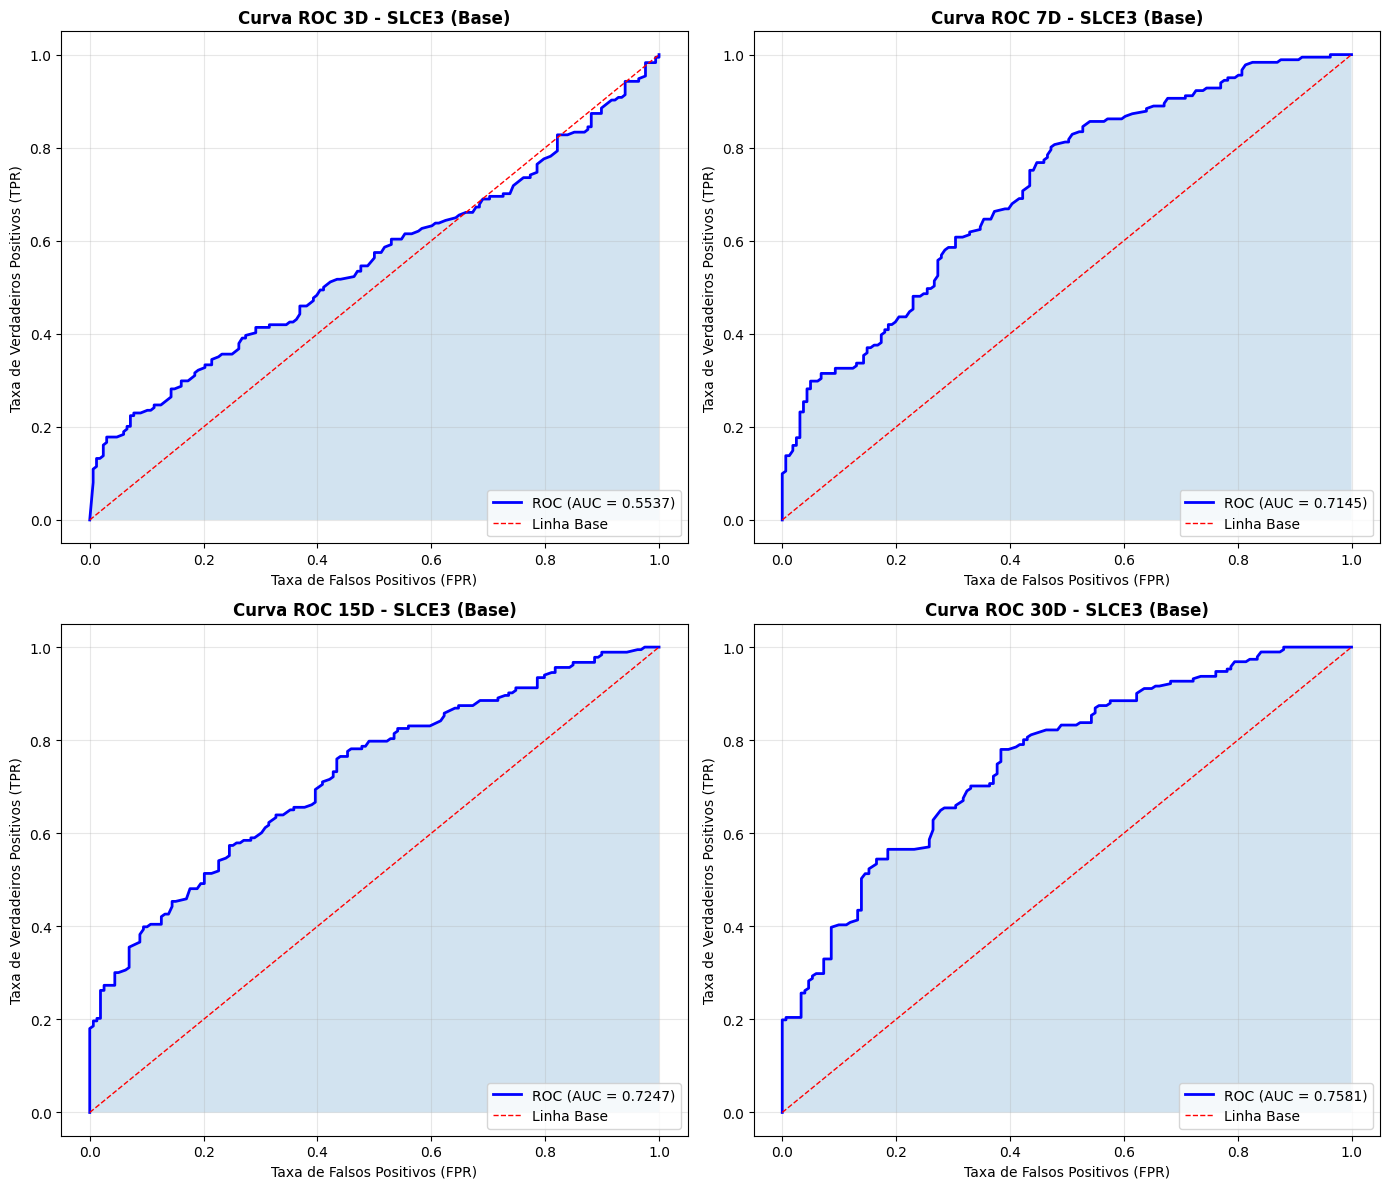

OK - Curvas ROC salvas


In [6]:
# Curvas ROC
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (period, model_data) in enumerate(models.items()):
    y_test = model_data['y_test']
    y_pred_proba = model_data['y_pred_proba']
    auc = model_data['auc_roc']

    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

    ax = axes[idx]
    ax.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC = {auc:.4f})')
    ax.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Linha Base')
    ax.fill_between(fpr, tpr, alpha=0.2)

    ax.set_title(f'Curva ROC {period.upper()} - SLCE3 (Base)', fontweight='bold')
    ax.set_xlabel('Taxa de Falsos Positivos (FPR)')
    ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR)')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}curva_roc_slce3_base.png', dpi=300, bbox_inches='tight')
plt.show()
print('OK - Curvas ROC salvas')

### Comparacao das Metricas por Horizonte

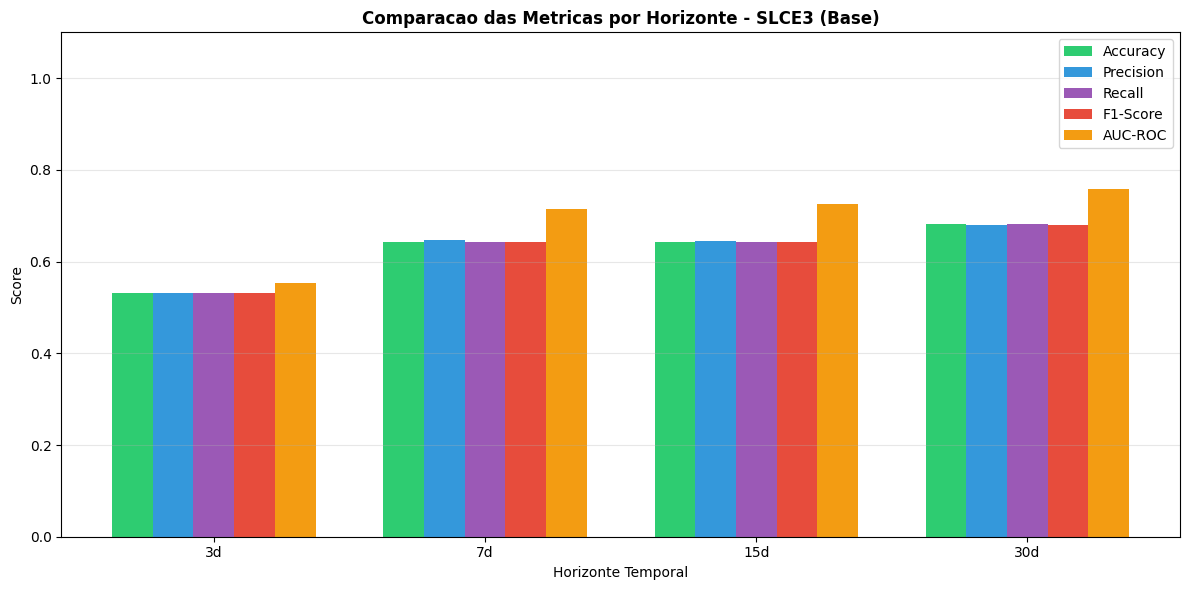

OK - Grafico de comparacao de metricas salvo


In [7]:
# Comparacao das metricas
periods = ['3d', '7d', '15d', '30d']
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']

accuracy_vals = [models[p]['accuracy'] for p in periods]
precision_vals = [models[p]['precision'] for p in periods]
recall_vals = [models[p]['recall'] for p in periods]
f1_vals = [models[p]['f1'] for p in periods]
auc_vals = [models[p]['auc_roc'] for p in periods]

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(periods))
width = 0.15

bars1 = ax.bar(x - 2 * width, accuracy_vals, width, label='Accuracy', color='#2ecc71')
bars2 = ax.bar(x - width, precision_vals, width, label='Precision', color='#3498db')
bars3 = ax.bar(x, recall_vals, width, label='Recall', color='#9b59b6')
bars4 = ax.bar(x + width, f1_vals, width, label='F1-Score', color='#e74c3c')
bars5 = ax.bar(x + 2 * width, auc_vals, width, label='AUC-ROC', color='#f39c12')

ax.set_xlabel('Horizonte Temporal')
ax.set_ylabel('Score')
ax.set_title('Comparacao das Metricas por Horizonte - SLCE3 (Base)', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(periods)
ax.legend(loc='upper right')
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}comparacao_metricas_slce3_base.png', dpi=300, bbox_inches='tight')
plt.show()
print('OK - Grafico de comparacao de metricas salvo')

### Evolucao das Metricas por Horizonte

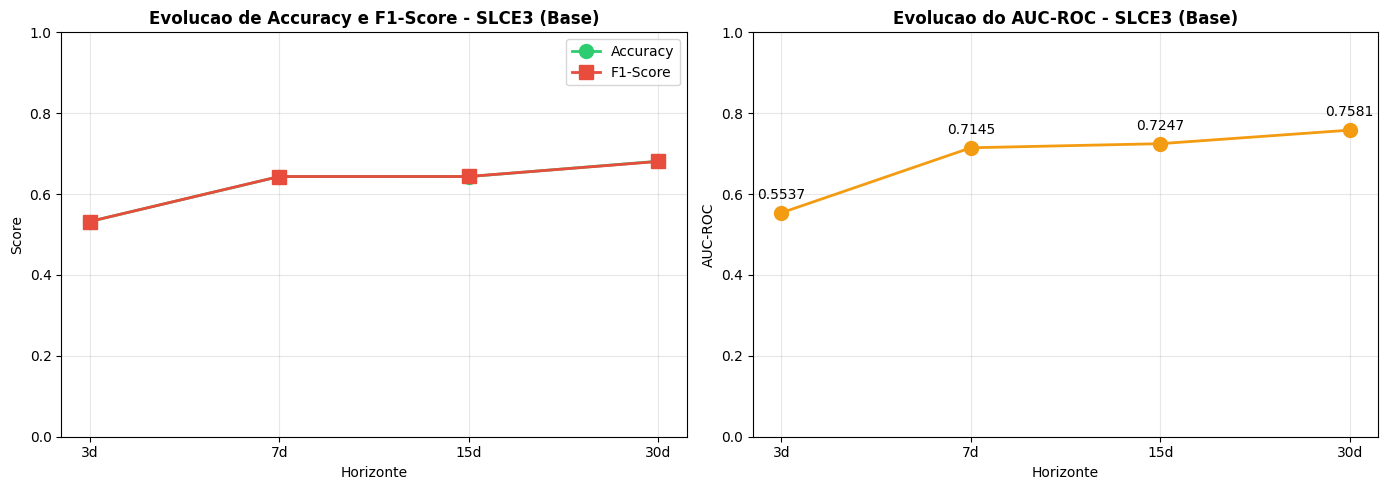

OK - Graficos de evolucao salvos


In [8]:
# Evolucao das metricas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Accuracy e F1-Score
axes[0].plot(periods, accuracy_vals, marker='o', linewidth=2, markersize=10, label='Accuracy', color='#2ecc71')
axes[0].plot(periods, f1_vals, marker='s', linewidth=2, markersize=10, label='F1-Score', color='#e74c3c')
axes[0].set_title('Evolucao de Accuracy e F1-Score - SLCE3 (Base)', fontweight='bold')
axes[0].set_xlabel('Horizonte')
axes[0].set_ylabel('Score')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1)

# Plot AUC-ROC
axes[1].plot(periods, auc_vals, marker='o', linewidth=2, markersize=10, color='#f39c12')
axes[1].set_title('Evolucao do AUC-ROC - SLCE3 (Base)', fontweight='bold')
axes[1].set_xlabel('Horizonte')
axes[1].set_ylabel('AUC-ROC')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1)

for i, v in enumerate(auc_vals):
    axes[1].annotate(f'{v:.4f}', (periods[i], v), textcoords='offset points', xytext=(0, 10), ha='center')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}evolucao_metricas_slce3_base.png', dpi=300, bbox_inches='tight')
plt.show()
print('OK - Graficos de evolucao salvos')

### Metricas da Classe Alta (Positiva)

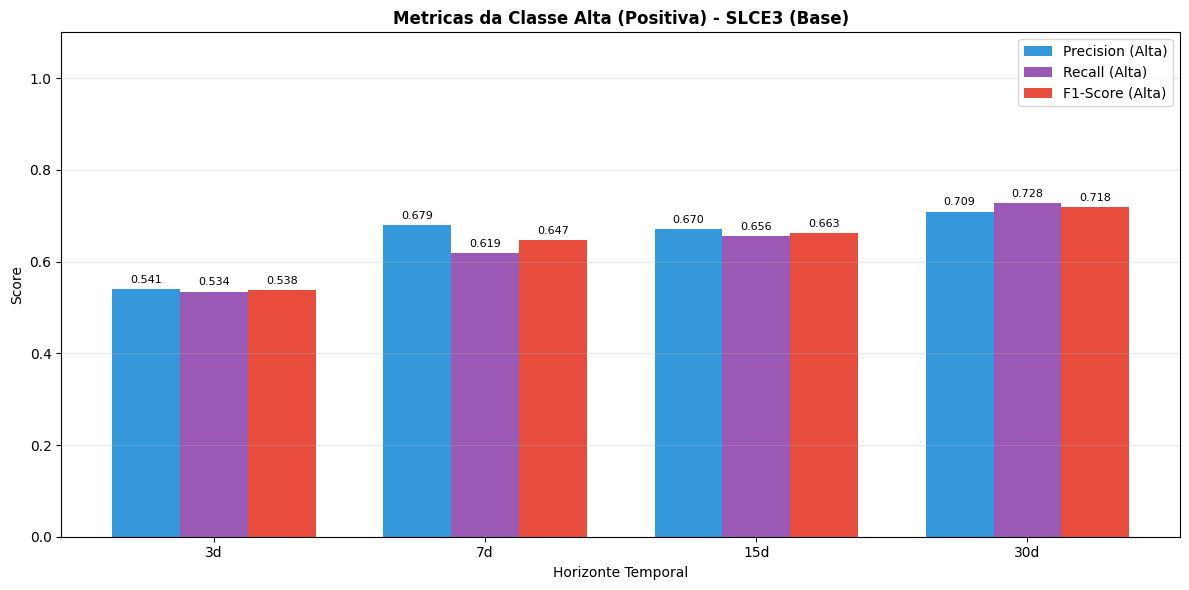

OK - Metricas da classe Alta salvas


In [9]:
# Metricas especificas da classe Alta
precision_alta_vals = [models[p]['precision_alta'] for p in periods]
recall_alta_vals = [models[p]['recall_alta'] for p in periods]
f1_alta_vals = [models[p]['f1_alta'] for p in periods]

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(periods))
width = 0.25

bars1 = ax.bar(x - width, precision_alta_vals, width, label='Precision (Alta)', color='#3498db')
bars2 = ax.bar(x, recall_alta_vals, width, label='Recall (Alta)', color='#9b59b6')
bars3 = ax.bar(x + width, f1_alta_vals, width, label='F1-Score (Alta)', color='#e74c3c')

ax.set_xlabel('Horizonte Temporal')
ax.set_ylabel('Score')
ax.set_title('Metricas da Classe Alta (Positiva) - SLCE3 (Base)', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(periods)
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3, axis='y')

# Adicionar valores nas barras
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}metricas_classe_alta_slce3_base.png', dpi=300, bbox_inches='tight')
plt.show()
print('OK - Metricas da classe Alta salvas')

### Relatorio de Classificacao Detalhado

In [10]:
# Relatorio de classificacao detalhado
print('\n' + '='*60)
print('RELATORIO DE CLASSIFICACAO DETALHADO - SLCE3 (BASE)')
print('='*60)

for period, model_data in models.items():
    print('\n' + '-' * 50)
    print(f'HORIZONTE: {period.upper()}')
    print('-' * 50)
    print(classification_report(model_data['y_test'], model_data['y_pred'], 
                                target_names=['Baixa/Estavel', 'Alta']))


RELATORIO DE CLASSIFICACAO DETALHADO - SLCE3 (BASE)

--------------------------------------------------
HORIZONTE: 3D
--------------------------------------------------
               precision    recall  f1-score   support

Baixa/Estavel       0.52      0.53      0.53       168
         Alta       0.54      0.53      0.54       174

     accuracy                           0.53       342
    macro avg       0.53      0.53      0.53       342
 weighted avg       0.53      0.53      0.53       342


--------------------------------------------------
HORIZONTE: 7D
--------------------------------------------------
               precision    recall  f1-score   support

Baixa/Estavel       0.61      0.67      0.64       161
         Alta       0.68      0.62      0.65       181

     accuracy                           0.64       342
    macro avg       0.64      0.64      0.64       342
 weighted avg       0.65      0.64      0.64       342


----------------------------------------------

### Resumo Final

In [11]:
print('\n' + '='*60)
print('RESUMO FINAL - RANDOM FOREST SLCE3 (DATASET BASE)')
print('='*60)
print('\nOK - 4 modelos treinados (horizontes: 3d, 7d, 15d, 30d)')
print(f'OK - Features: {base_features}')
print(f'OK - Total de features: {len(base_features)}')
print('\nMetricas por horizonte:')
for period in periods:
    m = models[period]
    print(f"  {period}: Acc={m['accuracy']:.4f}, F1={m['f1']:.4f}, AUC={m['auc_roc']:.4f}")

print('\nArquivos gerados:')
print('  - metricas_slce3_base.csv')
print('  - matriz_confusao_slce3_base.png')
print('  - curva_roc_slce3_base.png')
print('  - comparacao_metricas_slce3_base.png')
print('  - evolucao_metricas_slce3_base.png')
print('  - metricas_classe_alta_slce3_base.png')
print('='*60)


RESUMO FINAL - RANDOM FOREST SLCE3 (DATASET BASE)

OK - 4 modelos treinados (horizontes: 3d, 7d, 15d, 30d)
OK - Features: ['Close', 'Low', 'High', 'Open']
OK - Total de features: 4

Metricas por horizonte:
  3d: Acc=0.5322, F1=0.5322, AUC=0.5537
  7d: Acc=0.6433, F1=0.6435, AUC=0.7145
  15d: Acc=0.6433, F1=0.6435, AUC=0.7247
  30d: Acc=0.6813, F1=0.6807, AUC=0.7581

Arquivos gerados:
  - metricas_slce3_base.csv
  - matriz_confusao_slce3_base.png
  - curva_roc_slce3_base.png
  - comparacao_metricas_slce3_base.png
  - evolucao_metricas_slce3_base.png
  - metricas_classe_alta_slce3_base.png
